<h1 style="color:#003366; text-align:center; font-size:36px; font-weight:bold;">
Retail Banking EDA Project
</h1>

<h2 style="color:#003366; text-align:center; font-size:22px;">
Exploratory Data Analysis using Advanced DataFrame Operations
</h2>

<hr style="height:2px; background-color:#003366; border:none;">


<h2 style="color:#003366; font-size:22px; font-weight:bold;">
Project Description
</h2>

<p style="font-size:16px; color:#333; line-height:1.6;">
This project simulates a mid-sized retail bank’s internal data environment and focuses on advanced exploratory data analysis (EDA) using <b> Pandas</b>.<br>

You will work with multiple interlinked datasets — such as customers, accounts, transactions, and branch or merchant details — to explore patterns, detect anomalies, segment customers, and understand risk exposure.<br>

The emphasis is on applying <b>advanced DataFrame operations</b> like multi-key joins, group-based aggregations, resampling, reshaping, and conditional logic — all without using SQL or external libraries.
</p>


<h2 style="color:#003366; font-size:22px; font-weight:bold;">
Instructions to Learners
</h2>

<p style="font-size:16px; color:#333; line-height:1.6;">
This is a hands-on exploratory project using Pandas. You are expected to work only with the provided datasets: <b>customers</b>, <b>accounts</b>, and <b>transactions</b>. The focus is on applying advanced DataFrame operations for real-world banking analytics. The below solution is to be considered as a guidance only
</p>

<b>Some Guidelines:</b><br>

<ul style="font-size:16px; color:#333; line-height:1.8; margin-left:20px;">
  <li>Use <code>merge()</code> to join datasets wherever necessary. Do not use SQL or any external library for joins.</li>
  <li>Ensure time-based logic is respected — for example, transactions must not pre-date account opening.</li>
  <li>Do not hardcode values. Always write generalized, scalable code using Pandas operations.</li>
  <li>Use visual and numerical summaries (<code>groupby</code>, <code>pivot_table</code>, <code>value_counts</code>, <code>describe</code>) to support your answers.</li>
  <li>Wherever relevant, use <code>rolling()</code> or <code>resample()</code> to explore time-based patterns.</li>
  <li>Document your observations after each major step — your analysis should tell a data story.</li>
</ul>

<b>Deliverables:</b><br>
<ul style="font-size:16px; color:#333; line-height:1.8; margin-left:20px;">
  <li>Cleaned and well-validated DataFrames</li>
  <li>Answers to the questions/tasks listed below</li>
  <li>At least 3 well-labeled charts (line chart, bar chart, heatmap, etc.) showing meaningful patterns</li>
  <li>Markdown cells describing your insights in plain language</li>
</ul>


<h3 style="color:#003366;">Step 1: Load the Data</h3>

<p style="font-size:16px; color:#333;">
We will begin by loading the three core datasets:
<ul style="margin-left:20px;">
  <li><b>Customers</b>: Contains demographic and registration details of each customer</li>
  <li><b>Accounts</b>: Contains account-level details like type, status, open/close dates</li>
  <li><b>Transactions</b>: Contains transaction-level data with timestamps and channels</li>
</ul>

All datasets will be read from the <code>./data</code> folder. Date columns will be parsed as datetime objects, and we will take an initial look at their structure.
</p>


In [1]:
# Step 2: Import required libraries
import pandas as pd
import numpy as np

In [2]:
# Step 2: Define file paths
cust_path = "Customers_Data.csv"
acct_path = "Accounts_Data.csv"
txn_path  = "Transactions_Data.csv"

In [3]:
# Step 3: Read the CSVs into DataFrames with proper date parsing
# ----------------------------------------
# Note:
# - 'dob' and 'join_date' in customers
# - 'open_date' and 'close_date' in accounts
# - 'txn_date' in transactions
# ----------------------------------------
customers = pd.read_csv(cust_path, parse_dates=["dob", "join_date"])
accounts  = pd.read_csv(acct_path, parse_dates=["open_date", "close_date"])
transactions = pd.read_csv(txn_path, parse_dates=["txn_date"])

In [4]:
print("\n Customers:")
display(customers.head(2))


 Customers:


,customer_id,name,gender,dob,join_date,region,occupation
0,1001,Gaurav Ghosh,Male,1964-02-16,2016-05-10,East,Retired
1,1002,Kiran Khan,Male,1967-12-10,2021-10-31,West,Self-Employed


In [5]:
print("\n Accounts:")
display(accounts.head(2))


 Accounts:


,account_id,customer_id,account_type,open_date,status,close_date,branch_code
0,2001,1646,Savings,2024-02-17,Active,NaT,BR002
1,2002,1717,Current,2020-09-26,Active,NaT,BR005


In [6]:
print("\n Transactions:")
display(transactions.head(2))


 Transactions:


,txn_id,account_id,txn_date,amount,txn_type,channel
0,500001,2371,2021-07-31,2881.78,Debit,Branch
1,500002,2829,2022-10-28,1625.53,Debit,ATM


<h3 style="color:#003366;">Step 2: Dataset Structure & Missing Value Audit</h3>

<p style="font-size:16px; color:#333;">
In this step, we will examine the basic structure of the datasets:
<ul style="margin-left:20px;">
  <li>Number of rows and columns in each dataset</li>
  <li>Data types and null value counts</li>
  <li>Summary statistics for numerical columns (especially transaction amounts)</li>
  <li>Audit of expected vs unexpected nulls</li>
</ul>
This step helps ensure we understand the "shape" and cleanliness of the data before merging or deeper analysis.
</p>


In [8]:
print("Dataset Dimensions")
print("Customers:    ",customers.shape)
print("Accounts:     ",accounts.shape)
print("Transactions:    ",transactions.shape)

Dataset Dimensions
Customers:     (1000, 7)
Accounts:      (1500, 7)
Transactions:     (20000, 6)


In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  1000 non-null   int64         
 1   name         1000 non-null   object        
 2   gender       1000 non-null   object        
 3   dob          1000 non-null   datetime64[ns]
 4   join_date    1000 non-null   datetime64[ns]
 5   region       1000 non-null   object        
 6   occupation   1000 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 54.8+ KB


In [10]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    1500 non-null   int64         
 1   customer_id   1500 non-null   int64         
 2   account_type  1500 non-null   object        
 3   open_date     1500 non-null   datetime64[ns]
 4   status        1500 non-null   object        
 5   close_date    127 non-null    datetime64[ns]
 6   branch_code   1500 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 82.2+ KB


In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   txn_id      20000 non-null  int64         
 1   account_id  20000 non-null  int64         
 2   txn_date    20000 non-null  datetime64[ns]
 3   amount      20000 non-null  float64       
 4   txn_type    20000 non-null  object        
 5   channel     20000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 937.6+ KB


In [12]:
transactions["amount"].describe()

count    20000.000000
mean      2008.654798
std       1998.751736
min          0.060000
25%        575.885000
50%       1389.915000
75%       2790.532500
max      22311.560000
Name: amount, dtype: float64

In [15]:
print("Missing Values in Customer Dataset")
print(customers.isna().sum())

Missing Values in Customer Dataset
customer_id    0
name           0
gender         0
dob            0
join_date      0
region         0
occupation     0
dtype: int64


In [19]:
print(accounts.isna().sum())

account_id         0
customer_id        0
account_type       0
open_date          0
status             0
close_date      1373
branch_code        0
dtype: int64


In [23]:
print(transactions.isna().sum())

txn_id        0
account_id    0
txn_date      0
amount        0
txn_type      0
channel       0
dtype: int64


<h3 style="color:#003366;">Step 3: Merging the Datasets for Unified Analysis</h3>

<p style="font-size:16px; color:#333;">
Our three datasets are interconnected via primary and foreign keys:
<ul style="margin-left:20px;">
  <li><code>accounts.customer_id</code> links each account to its corresponding customer</li>
  <li><code>transactions.account_id</code> links each transaction to its corresponding account</li>
</ul>

We will now:
<ol style="margin-left:20px;">
  <li>Join <b>accounts</b> with <b>customers</b> to create an enriched account dataset</li>
  <li>Join <b>transactions</b> with the enriched account dataset to create a final dataframe: <code>txn_full</code></li>
</ol>

This merged dataframe will allow us to analyze customer and transaction behavior in a single unified view.
</p>


In [31]:
acct_full=pd.merge(accounts,customers, on="customer_id", how="left")
acct_full.shape

(1500, 13)

In [33]:
txn_full=pd.merge(transactions,acct_full, on='account_id',how='left')
txn_full.shape

(20000, 18)

<h4 style="color:#003366;">Post-Join Checks</h4>

<p style="font-size:16px; color:#333;">
To confirm that our joins have succeeded:
<ul style="margin-left:20px;">
  <li>We should see new fields like <code>account_type</code>, <code>branch_code</code>, <code>region</code>, and <code>occupation</code> in the transaction dataframe</li>
  <li>No columns should be entirely null after the merge (aside from <code>close_date</code>)</li>
</ul>

This merged dataframe — <code>txn_full</code> — will now serve as the base for all downstream analyses.
</p>


In [36]:
txn_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   txn_id        20000 non-null  int64         
 1   account_id    20000 non-null  int64         
 2   txn_date      20000 non-null  datetime64[ns]
 3   amount        20000 non-null  float64       
 4   txn_type      20000 non-null  object        
 5   channel       20000 non-null  object        
 6   customer_id   20000 non-null  int64         
 7   account_type  20000 non-null  object        
 8   open_date     20000 non-null  datetime64[ns]
 9   status        20000 non-null  object        
 10  close_date    1626 non-null   datetime64[ns]
 11  branch_code   20000 non-null  object        
 12  name          20000 non-null  object        
 13  gender        20000 non-null  object        
 14  dob           20000 non-null  datetime64[ns]
 15  join_date     20000 non-null  dateti

In [38]:
txn_full.head(2)

,txn_id,account_id,txn_date,amount,txn_type,channel,customer_id,account_type,open_date,status,close_date,branch_code,name,gender,dob,join_date,region,occupation
0,500001,2371,2021-07-31,2881.78,Debit,Branch,1970,Salary,2021-07-22,Active,NaT,BR002,Ria Khan,Male,1998-05-14,2015-12-07,East,Self-Employed
1,500002,2829,2022-10-28,1625.53,Debit,ATM,1628,Savings,2022-04-16,Active,NaT,BR001,Arjun Patel,Male,1976-12-31,2018-08-01,East,Salaried


<h3 style="color:#003366;">Step 4 – Task 1: Segment Customers by Region and Occupation</h3>

<p style="font-size:16px; color:#333;">
We start our exploratory journey by analyzing the distribution of customers across different <b>regions</b> and <b>occupations</b>.
This helps answer:
<ul style="margin-left:20px;">
  <li>Which regions dominate the customer base?</li>
  <li>What kinds of occupations are common in each zone?</li>
</ul>
We will use <code>groupby()</code> and <code>pivot_table()</code> to count customers
</p>


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
temp1=txn_full.groupby("region")["customer_id"].nunique()
temp1

region
East     193
North    201
South    196
West     184
Name: customer_id, dtype: int64

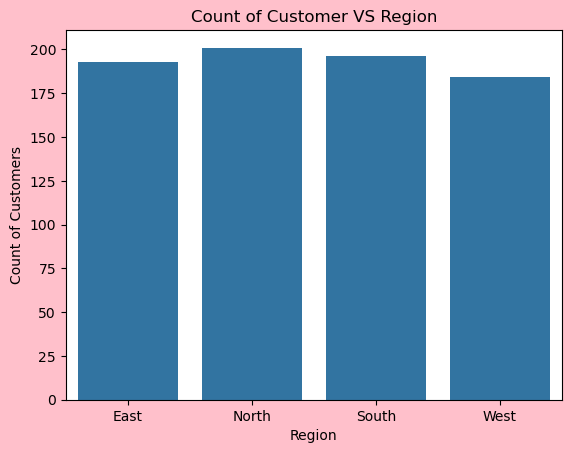

In [73]:
plt.figure(facecolor="pink")
sns.barplot(temp1)
plt.xlabel("Region")
plt.ylabel("Count of Customers")
plt.title("Count of Customer VS Region")
plt.show()

In [59]:
temp2=pd.pivot_table(data=txn_full,index="region",columns="occupation",values="customer_id",aggfunc="nunique")
temp2

occupation,Retired,Salaried,Self-Employed,Student
region,,,,
East,52,43,40,58
North,44,55,49,53
South,50,40,60,46
West,49,55,39,41


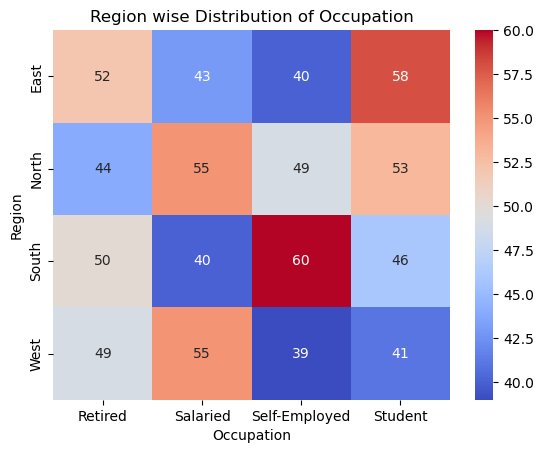

In [79]:
sns.heatmap(temp2,annot=True,cmap="coolwarm")
plt.xlabel("Occupation")
plt.ylabel("Region")
plt.title("Region wise Distribution of Occupation")
plt.show()

<h3 style="color:#003366;">Step 4 – Task 2A: Transaction Volume and Average Amount</h3>

<p style="font-size:16px; color:#333;">
In this task, we analyze how customers use different <b>account types</b> and <b>transaction channels</b>.
This helps uncover:
<ul style="margin-left:20px;">
  <li>Which combinations produce the most traffic</li>
  <li>Where high-value transactions are happening</li>
</ul>
We will compute transaction volume, total amount, and average amount for each <code>(account_type, channel)</code> pair.
</p>


In [155]:
# d={"txn_id":["count"],"amount":["sum","mean"]}
temp3=txn_full.groupby(["account_type","channel"]).agg(
    txn_count=('txn_id','count'),
    total_amount=('amount','sum'),
    avg_amount=('amount','mean')
).reset_index().round(0)
temp3

,account_type,channel,txn_count,total_amount,avg_amount
0,Current,ATM,1742,3558095.0,2043.0
1,Current,Branch,1780,3649984.0,2051.0
2,Current,Online,1705,3385090.0,1985.0
3,Current,POS,1682,3283016.0,1952.0
4,Salary,ATM,1710,3407311.0,1993.0
5,Salary,Branch,1672,3340479.0,1998.0
6,Salary,Online,1674,3334914.0,1992.0
7,Salary,POS,1713,3402709.0,1986.0
8,Savings,ATM,1562,3155235.0,2020.0
9,Savings,Branch,1598,3280649.0,2053.0


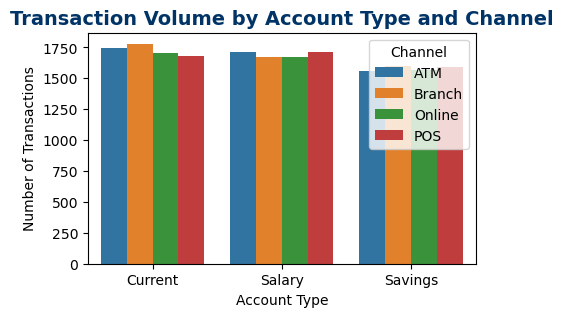

In [110]:
plt.figure(figsize=(5, 3))
sns.barplot(data=temp3, x='account_type', y='txn_count', hue='channel')
plt.title("Transaction Volume by Account Type and Channel", fontsize=14, weight='bold', color='#003366')
plt.xlabel("Account Type")
plt.ylabel("Number of Transactions")
plt.legend(title="Channel")
plt.show()

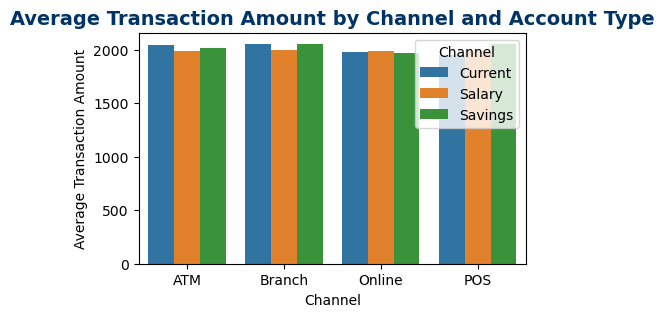

In [120]:
plt.figure(figsize=(5, 3))
sns.barplot(data=temp3, x='channel', y='avg_amount', hue='account_type')
plt.title("Average Transaction Amount by Channel and Account Type", fontsize=14, weight='bold', color='#003366')
plt.xlabel("Channel")
plt.ylabel("Average Transaction Amount")
plt.legend(title="Channel")
plt.show()

<h3 style="color:#003366;">Step 4 – Task 3: Customer-Level Profiling</h3>

<p style="font-size:16px; color:#333;">
In this task, we shift our focus to individual customer behavior and extract insights like:
<ul style="margin-left:20px;">
  <li>Who are the highest spenders?</li>
  <li>Who transacts the most frequently?</li>
  <li>Which customers are inactive or dormant?</li>
</ul>
These insights help businesses with targeting, retention, and risk strategies.
</p>


In [141]:
cust_profile=txn_full.groupby('customer_id').agg(
    total_txn=('txn_id','count'),
    total_spent=('amount','sum'),
    avg_txn_amt=('amount','mean'),
    first_txn_date=('txn_date','min'),
    last_txn_date=('txn_date','max'),
    unique_channels=('channel','nunique')
).reset_index()
cust_profile
cust_profile = cust_profile.merge(customers, on="customer_id", how="left")
cust_profile

,customer_id,total_txn,total_spent,avg_txn_amt,first_txn_date,last_txn_date,unique_channels,name,gender,dob,join_date,region,occupation
0,1001,22,39842.43,1811.019545,2019-10-27,2025-08-04,4,Gaurav Ghosh,Male,1964-02-16,2016-05-10,East,Retired
1,1002,15,37833.64,2522.242667,2023-11-24,2025-08-09,4,Kiran Khan,Male,1967-12-10,2021-10-31,West,Self-Employed
2,1003,13,18768.95,1443.765385,2021-11-20,2025-07-28,4,Sara Sharma,Female,1977-08-09,2020-11-17,East,Retired
3,1004,15,47795.76,3186.384000,2024-03-27,2025-05-23,4,Zoya Kulkarni,Female,1960-07-18,2019-02-25,East,Student
4,1006,28,51008.39,1821.728214,2022-10-04,2025-08-18,4,Neha Bhat,Female,1958-11-15,2022-07-05,North,Salaried
...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,1996,34,91782.72,2699.491765,2022-02-02,2025-08-02,4,Rahul Iyer,Male,2006-05-16,2020-08-25,West,Self-Employed
770,1997,58,110570.34,1906.385172,2021-01-10,2025-05-30,4,Aarav Menon,Female,1977-09-13,2019-11-08,South,Student
771,1998,78,127272.06,1631.693077,2020-03-17,2025-08-19,4,Dev Khan,Female,1954-08-28,2018-07-12,South,Self-Employed
772,1999,10,20942.84,2094.284000,2024-07-13,2025-08-12,4,Sonia Nair,Female,1992-07-27,2023-05-03,South,Salaried


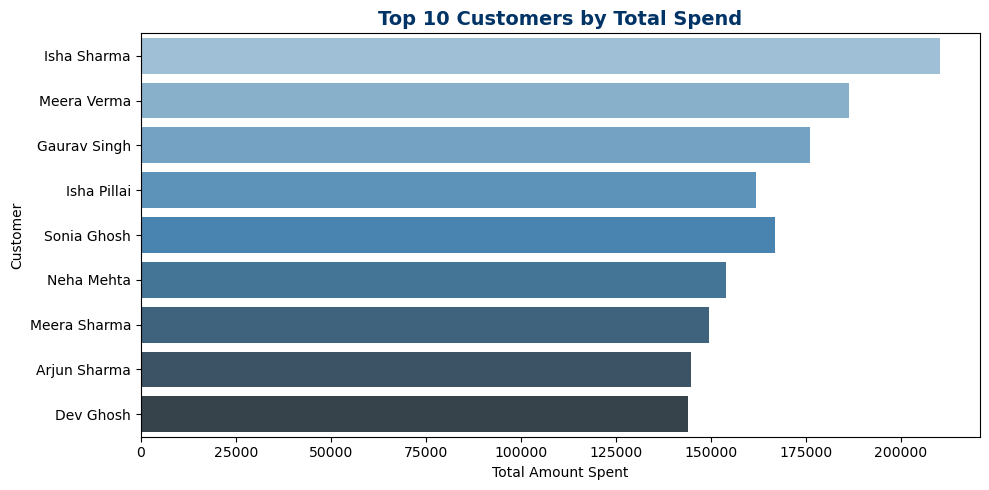

In [143]:
top_spenders = cust_profile.sort_values(by="total_spent", ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_spenders, x="total_spent", y="name", palette="Blues_d", hue='name',errorbar=None)
plt.title("Top 10 Customers by Total Spend", fontsize=14, weight='bold', color="#003366")
plt.xlabel("Total Amount Spent")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()


In [145]:
txn_full[txn_full["status"]=="Dormant"][["name","account_id"]].drop_duplicates()

,name,account_id
5,Dev Mehta,3011
8,Kabir Patel,2683
13,Aditya Kulkarni,2526
15,Sara Bhat,3081
16,Aisha Kapoor,3416
...,...,...
6117,Ravi Ghosh,2983
6389,Ishaan Menon,2417
6677,Neha Sharma,2508
6706,Sonia Nair,3193
